In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import statsmodels
import statsmodels.api as sm
from scipy.stats import chi2_contingency
from scipy.stats import norm
from statsmodels.stats.proportion import proportions_ztest
from IPython.display import display
from google.colab import files

warnings.filterwarnings("ignore")  # Hide non-critical warning messages to keep the notebook output clean.
pd.set_option("display.max_columns", None)  # Configure Pandas to display all DataFrame columns.
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")  # Display decimal values using six decimal places.
np.random.seed(42)  # Set a fixed random seed to make simulation results reproducible.
plt.rcParams["figure.figsize"] = (10, 6)  # Set the default chart size for all Matplotlib visualizations.
plt.rcParams["axes.titlesize"] = 14  # Set the default chart title font size.
plt.rcParams["axes.labelsize"] = 11  # Set the default axis-label font size.
plt.rcParams["figure.dpi"] = 100  # Set the default chart resolution.

In [2]:
try:  # Start an error-handling block for safely loading the CSV files.
    ab_df = pd.read_csv("/content/ab_data.csv")
    countries_df = pd.read_csv("/content/countries.csv")
    print("Both datasets were loaded successfully.")
except FileNotFoundError as error:
    print("A required CSV file was not found.")  # Display a user-friendly file-not-found message.
    print(error)

Both datasets were loaded successfully.


## Preserve Raw Copies

Before modifying the datasets, separate backup copies are created.

This ensures that the original raw data remains available for validation, comparison, and reproducibility.

In [3]:
ab_raw = ab_df.copy()  # Create an unchanged backup copy of the original A/B testing dataset.
countries_raw = countries_df.copy()
print("Raw backup copies were created successfully.")  # Confirm that both raw dataset backups were created.

Raw backup copies were created successfully.


In [4]:
print("First five rows of the A/B testing dataset:")
display(ab_df.head())

print("\nFirst five rows of the country dataset:")
display(countries_df.head())

First five rows of the A/B testing dataset:


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1



First five rows of the country dataset:


,user_id,country
0,834778,UK
1,928468,US
2,822059,UK
3,711597,UK
4,710616,UK


## Data Audit Function

A reusable audit function is created to summarize each dataset.

The function reports:

- Number of rows and columns
- Column names
- Data types
- Missing values
- Duplicate rows
- Unique values
- Sample observations

In [5]:
def audit_dataframe(dataframe, dataframe_name):  # Define a reusable function for auditing any DataFrame.
    print("=" * 80)
    print(f"DATA AUDIT: {dataframe_name}")
    print("=" * 80)

    print(f"Number of rows: {dataframe.shape[0]:,}")  # Display the total number of observations in the dataset.
    print(f"Number of columns: {dataframe.shape[1]:,}")  # Display the total number of variables in the dataset.
    print(f"Duplicate rows: {dataframe.duplicated().sum():,}")  # Count and display completely duplicated rows.

    print("\nColumn names:")
    print(dataframe.columns.tolist())  # Display all column names as a Python list.

    print("\nData types:")
    display(dataframe.dtypes.rename("data_type").to_frame())  # Display each column and its corresponding data type.

    print("\nMissing values:")
    display(dataframe.isna().sum().rename("missing_values").to_frame())  # Display the number of missing values in each column.

    print("\nNumber of unique values:")
    display(dataframe.nunique(dropna=False).rename("unique_values").to_frame())  # Display the number of unique values in each column.

    print("\nFirst five rows:")
    display(dataframe.head())  # Display the first five observations from the dataset.

In [6]:
audit_dataframe(ab_df, "A/B Testing Dataset")  # Run the audit function on the main A/B testing dataset.
audit_dataframe(countries_df, "Country Dataset")  # Run the audit function on the country dataset.

DATA AUDIT: A/B Testing Dataset
Number of rows: 294,478
Number of columns: 5
Duplicate rows: 0

Column names:
['user_id', 'timestamp', 'group', 'landing_page', 'converted']

Data types:


,data_type
user_id,int64
timestamp,object
group,object
landing_page,object
converted,int64



Missing values:


,missing_values
user_id,0
timestamp,0
group,0
landing_page,0
converted,0



Number of unique values:


...

,missing_values
user_id,0
country,0



Number of unique values:


,unique_values
user_id,290584
country,3



First five rows:


,user_id,country
0,834778,UK
1,928468,US
2,822059,UK
3,711597,UK
4,710616,UK


## Validate Required Columns

The analysis requires a specific set of columns.

This validation ensures that the uploaded datasets have the expected structure before data cleaning begins.

In [7]:
required_ab_columns = {"user_id", "timestamp", "group", "landing_page", "converted"}  # Define the required columns for the A/B dataset.
required_country_columns = {"user_id", "country"}  # Define the required columns for the country dataset.

missing_ab_columns = required_ab_columns.difference(ab_df.columns)  # Identify required A/B columns that are missing.
missing_country_columns = required_country_columns.difference(countries_df.columns)  # Identify required country columns that are missing.

print(f"Missing A/B dataset columns: {missing_ab_columns}")  # Display missing columns from the A/B dataset.
print(f"Missing country dataset columns: {missing_country_columns}")  # Display missing columns from the country dataset.

assert len(missing_ab_columns) == 0, "The A/B dataset is missing one or more required columns."  # Stop execution when a required A/B column is absent.
assert len(missing_country_columns) == 0, "The country dataset is missing one or more required columns."  # Stop execution when a required country column is absent.

print("Required-column validation completed successfully.")  # Confirm that all required columns are available.

Missing A/B dataset columns: set()
Missing country dataset columns: set()
Required-column validation completed successfully.


## Inspect Categorical Variables

The unique values and frequency distributions of the categorical variables are examined.

This helps detect unexpected labels, spelling differences, invalid categories, and class imbalance.

In [8]:
group_distribution = ab_df["group"].value_counts(dropna=False).rename_axis("group").reset_index(name="row_count")  # Count observations in each experimental group.
page_distribution = ab_df["landing_page"].value_counts(dropna=False).rename_axis("landing_page").reset_index(name="row_count")  # Count observations for each landing-page version.
conversion_distribution = ab_df["converted"].value_counts(dropna=False).sort_index().rename_axis("converted").reset_index(name="row_count")  # Count converted and non-converted observations.
country_distribution = countries_df["country"].value_counts(dropna=False).rename_axis("country").reset_index(name="user_count")  # Count users belonging to each country.

print("Experiment group distribution:")
display(group_distribution)  # Display control and treatment observation counts.

print("\nLanding-page distribution:")
display(page_distribution)  # Display old-page and new-page observation counts.

print("\nConversion outcome distribution:")
display(conversion_distribution)  # Display conversion outcome counts.

print("\nCountry distribution:")
display(country_distribution)  # Display user counts for each country.

Experiment group distribution:


,group,row_count
0,treatment,147276
1,control,147202



Landing-page distribution:


,landing_page,row_count
0,old_page,147239
1,new_page,147239



Conversion outcome distribution:


,converted,row_count
0,0,259241
1,1,35237



Country distribution:


,country,user_count
0,US,203619
1,UK,72466
2,CA,14499


##  Validate Expected Category Values

The experiment is expected to contain only the following values:

- Group: `control` or `treatment`
- Landing page: `old_page` or `new_page`
- Conversion: `0` or `1`

Unexpected values could indicate data-entry or processing errors.

In [9]:
expected_groups = {"control", "treatment"}  # Define the valid experimental group labels.
expected_pages = {"old_page", "new_page"}  # Define the valid landing-page labels.
expected_conversion_values = {0, 1}  # Define the valid binary conversion outcomes.

actual_groups = set(ab_df["group"].dropna().unique())  # Extract the observed non-missing group labels.
actual_pages = set(ab_df["landing_page"].dropna().unique())  # Extract the observed non-missing landing-page labels.
actual_conversion_values = set(ab_df["converted"].dropna().unique())  # Extract the observed non-missing conversion outcomes.

invalid_groups = actual_groups.difference(expected_groups)  # Identify unexpected group labels.
invalid_pages = actual_pages.difference(expected_pages)  # Identify unexpected landing-page labels.
invalid_conversion_values = actual_conversion_values.difference(expected_conversion_values)  # Identify unexpected conversion values.

print(f"Invalid group values: {invalid_groups}")
print(f"Invalid landing-page values: {invalid_pages}")
print(f"Invalid conversion values: {invalid_conversion_values}")

Invalid group values: set()
Invalid landing-page values: set()
Invalid conversion values: set()


In [10]:
ab_missing_summary = ab_df.isna().sum().rename("missing_count").to_frame()  # Calculate missing-value counts for every A/B dataset column.
ab_missing_summary["missing_percentage"] = ab_missing_summary["missing_count"] / len(ab_df) * 100  # Calculate missing-value percentages for the A/B dataset.

country_missing_summary = countries_df.isna().sum().rename("missing_count").to_frame()  # Calculate missing-value counts for every country dataset column.
country_missing_summary["missing_percentage"] = country_missing_summary["missing_count"] / len(countries_df) * 100  # Calculate missing-value percentages for the country dataset.

print("Missing-value summary for the A/B dataset:")
display(ab_missing_summary)

print("\nMissing-value summary for the country dataset:")
display(country_missing_summary)

Missing-value summary for the A/B dataset:


,missing_count,missing_percentage
user_id,0,0.000000
timestamp,0,0.000000
group,0,0.000000
landing_page,0,0.000000
converted,0,0.000000



Missing-value summary for the country dataset:


,missing_count,missing_percentage
user_id,0,0.000000
country,0,0.000000


In [11]:
duplicate_ab_rows = ab_df.duplicated().sum()  # Count completely duplicated rows in the A/B dataset.
duplicate_ab_user_rows = ab_df["user_id"].duplicated(keep=False).sum()  # Count all rows belonging to repeated user IDs.
duplicate_ab_user_ids = ab_df.loc[ab_df["user_id"].duplicated(keep=False), "user_id"].nunique()  # Count unique user IDs appearing more than once.
duplicate_country_rows = countries_df.duplicated().sum()  # Count completely duplicated rows in the country dataset.
duplicate_country_user_ids = countries_df["user_id"].duplicated(keep=False).sum()  # Count rows belonging to repeated country user IDs.

user_group_counts = ab_df.groupby("user_id")["group"].nunique()  # Count how many different experiment groups each user belongs to.
multi_group_user_count = (user_group_counts > 1).sum()  # Count users assigned to more than one experimental group.

user_page_counts = ab_df.groupby("user_id")["landing_page"].nunique()  # Count how many different page versions each user received.
multi_page_user_count = (user_page_counts > 1).sum()  # Count users shown more than one landing-page version.

print(f"Completely duplicated A/B rows: {duplicate_ab_rows:,}")
print(f"Rows belonging to repeated A/B users: {duplicate_ab_user_rows:,}")
print(f"Unique repeated A/B user IDs: {duplicate_ab_user_ids:,}")
print(f"Users assigned to multiple groups: {multi_group_user_count:,}")
print(f"Users shown multiple page versions: {multi_page_user_count:,}")
print(f"Completely duplicated country rows: {duplicate_country_rows:,}")
print(f"Rows belonging to repeated country user IDs: {duplicate_country_user_ids:,}")

Completely duplicated A/B rows: 0
Rows belonging to repeated A/B users: 7,788
Unique repeated A/B user IDs: 3,894
Users assigned to multiple groups: 1,895
Users shown multiple page versions: 1,998
Completely duplicated country rows: 0
Rows belonging to repeated country user IDs: 0


In [12]:
repeated_user_records = ab_df.loc[ab_df["user_id"].duplicated(keep=False)].sort_values(["user_id", "timestamp"])  # Extract and sort all records belonging to duplicated users.
print("Repeated user records:")  # Print a heading for repeated-user observations.
display(repeated_user_records)  # Display all repeated-user records for manual inspection.

Repeated user records:


,user_id,timestamp,group,landing_page,converted
213114,630052,2017-01-07 12:25:54.089486,treatment,old_page,1
230259,630052,2017-01-17 01:16:05.208766,treatment,new_page,0
22513,630126,2017-01-14 13:35:54.778695,treatment,old_page,0
251762,630126,2017-01-19 17:16:00.280440,treatment,new_page,0
183371,630137,2017-01-20 02:08:49.893878,control,old_page,0
...,...,...,...,...,...
99479,945703,2017-01-18 06:39:31.294688,control,old_page,0
40370,945797,2017-01-11 03:04:49.433736,control,new_page,1
186960,945797,2017-01-13 17:23:21.750962,control,old_page,0
165143,945971,2017-01-16 10:09:18.383183,control,old_page,0


## Group and Landing-Page Consistency

A valid experiment assignment should follow this structure:

- Control users should receive the old page.
- Treatment users should receive the new page.

Records that violate this mapping may represent assignment or logging errors and must be removed before analysis.

In [13]:
control_new_mask = (ab_df["group"] == "control") & (ab_df["landing_page"] == "new_page")  # Identify control users incorrectly shown the new page.
treatment_old_mask = (ab_df["group"] == "treatment") & (ab_df["landing_page"] == "old_page")  # Identify treatment users incorrectly shown the old page.
mismatch_mask = control_new_mask | treatment_old_mask  # Combine both types of invalid experiment assignments.

control_new_count = control_new_mask.sum()  # Count control users incorrectly shown the new page.
treatment_old_count = treatment_old_mask.sum()  # Count treatment users incorrectly shown the old page.
total_mismatch_count = mismatch_mask.sum()  # Count all inconsistent group-page assignments.

print(f"Control users shown the new page: {control_new_count:,}")
print(f"Treatment users shown the old page: {treatment_old_count:,}")
print(f"Total mismatched records: {total_mismatch_count:,}")

Control users shown the new page: 1,928
Treatment users shown the old page: 1,965
Total mismatched records: 3,893


## Timestamp Validation

The timestamp column is tested to determine whether every value can be converted into a valid datetime object.

Valid timestamps are required for date, weekday, hour, and experiment-duration analysis.

In [14]:
parsed_timestamp_check = pd.to_datetime(ab_df["timestamp"], errors="coerce")  # Convert timestamps temporarily and replace invalid values with missing values.
invalid_timestamp_count = parsed_timestamp_check.isna().sum()  # Count timestamp values that could not be converted.
experiment_start = parsed_timestamp_check.min()  # Identify the earliest valid experiment timestamp.
experiment_end = parsed_timestamp_check.max()  # Identify the latest valid experiment timestamp.

print(f"Invalid timestamp values: {invalid_timestamp_count:,}")
print(f"Experiment start: {experiment_start}")
print(f"Experiment end: {experiment_end}")
print(f"Experiment duration: {experiment_end - experiment_start}")

Invalid timestamp values: 0
Experiment start: 2017-01-02 13:42:05.378582
Experiment end: 2017-01-24 13:41:54.460509
Experiment duration: 21 days 23:59:49.081927


## Country Dataset Coverage

Before merging, the user IDs in the two datasets are compared.

This verifies whether country information is available for every unique user in the experiment.

In [15]:
unique_ab_users = set(ab_df["user_id"].unique())  # Create a set containing all unique users in the A/B dataset.
unique_country_users = set(countries_df["user_id"].unique())  # Create a set containing all unique users in the country dataset.

ab_users_without_country = unique_ab_users.difference(unique_country_users)  # Identify experiment users without a matching country record.
country_users_without_ab_data = unique_country_users.difference(unique_ab_users)  # Identify country users without a matching experiment record.

print(f"Unique users in the A/B dataset: {len(unique_ab_users):,}")
print(f"Unique users in the country dataset: {len(unique_country_users):,}")
print(f"A/B users without country information: {len(ab_users_without_country):,}")
print(f"Country users without A/B records: {len(country_users_without_ab_data):,}")

Unique users in the A/B dataset: 290,584
Unique users in the country dataset: 290,584
A/B users without country information: 0
Country users without A/B records: 0


##  Data Cleaning Strategy

The following cleaning actions will be applied:

1. Retain only valid group-page assignments.
2. Remove repeated users so that each user contributes one observation.
3. Convert the timestamp column into datetime format.
4. Remove records with missing essential experimental fields.
5. Standardize country labels.
6. Remove duplicate country user IDs if present.
7. Merge the experiment and country datasets.
8. Validate the final analytical dataset.

These steps ensure that the statistical analysis is based on consistent and independent user-level observations.

In [16]:
ab_clean = ab_df.copy()  # Create a working copy of the A/B dataset for cleaning.
rows_before_assignment_cleaning = len(ab_clean)  # Store the row count before removing invalid assignments.

valid_assignment_mask = ((ab_clean["group"] == "control") & (ab_clean["landing_page"] == "old_page")) | ((ab_clean["group"] == "treatment") & (ab_clean["landing_page"] == "new_page"))  # Identify observations with valid group-page assignments.
ab_clean = ab_clean.loc[valid_assignment_mask].copy()  # Retain only correctly assigned experiment observations.

rows_after_assignment_cleaning = len(ab_clean)  # Store the row count after removing invalid assignments.
removed_assignment_rows = rows_before_assignment_cleaning - rows_after_assignment_cleaning  # Calculate the number of invalid assignment rows removed.

print(f"Rows before assignment cleaning: {rows_before_assignment_cleaning:,}")
print(f"Invalid assignment rows removed: {removed_assignment_rows:,}")
print(f"Rows after assignment cleaning: {rows_after_assignment_cleaning:,}")

Rows before assignment cleaning: 294,478
Invalid assignment rows removed: 3,893
Rows after assignment cleaning: 290,585


In [17]:
duplicate_records_after_assignment_cleaning = ab_clean.loc[ab_clean["user_id"].duplicated(keep=False)].sort_values(["user_id", "timestamp"])  # Extract duplicated users remaining after assignment cleaning.
duplicate_user_count_before_removal = duplicate_records_after_assignment_cleaning["user_id"].nunique()  # Count unique users that still appear more than once.

print(f"Repeated users remaining before duplicate removal: {duplicate_user_count_before_removal:,}")  # Display the number of duplicated users.
display(duplicate_records_after_assignment_cleaning)  # Display the repeated records before removing duplicates.

Repeated users remaining before duplicate removal: 1


,user_id,timestamp,group,landing_page,converted
1899,773192,2017-01-09 05:37:58.781806,treatment,new_page,0
2893,773192,2017-01-14 02:55:59.590927,treatment,new_page,0


In [18]:
rows_before_duplicate_removal = len(ab_clean)  # Store the row count before removing repeated users.
ab_clean = ab_clean.drop_duplicates(subset="user_id", keep="first").copy()  # Retain the first observation for each user and remove later duplicates.
rows_after_duplicate_removal = len(ab_clean)  # Store the row count after duplicate removal.
removed_duplicate_rows = rows_before_duplicate_removal - rows_after_duplicate_removal  # Calculate the number of repeated-user rows removed.

print(f"Duplicate user rows removed: {removed_duplicate_rows:,}")
print(f"Rows remaining after duplicate removal: {rows_after_duplicate_removal:,}")
print(f"Every user is unique: {ab_clean['user_id'].is_unique}")

Duplicate user rows removed: 1
Rows remaining after duplicate removal: 290,584
Every user is unique: True


## Convert Timestamp and Handle Missing Core Values

The timestamp column is converted to datetime format.

Rows missing essential experimental variables are removed because they cannot be used reliably in the A/B test or regression analysis.

In [19]:
ab_clean["timestamp"] = pd.to_datetime(ab_clean["timestamp"], errors="coerce")  # Convert the timestamp column into Pandas datetime format.
required_analysis_columns = ["user_id", "timestamp", "group", "landing_page", "converted"]  # Define the essential columns required for statistical analysis.

rows_before_missing_removal = len(ab_clean)  # Store the row count before removing records with missing essential values.
ab_clean = ab_clean.dropna(subset=required_analysis_columns).copy()  # Remove observations missing any essential analytical variable.
rows_after_missing_removal = len(ab_clean)  # Store the row count after removing missing essential values.
removed_missing_rows = rows_before_missing_removal - rows_after_missing_removal  # Calculate the number of incomplete rows removed.

ab_clean["converted"] = ab_clean["converted"].astype(int)  # Convert the binary conversion outcome to integer format.

print(f"Rows removed because of missing essential values: {removed_missing_rows:,}")
print(f"Timestamp data type: {ab_clean['timestamp'].dtype}")
print(f"Conversion data type: {ab_clean['converted'].dtype}")

Rows removed because of missing essential values: 0
Timestamp data type: datetime64[ns]
Conversion data type: int64


## Clean the Country Dataset

Country labels are standardized by removing unnecessary spaces and converting the values to uppercase.

Duplicate country user IDs and records with missing essential information are also removed.

In [20]:
countries_clean = countries_df.copy()  # Create a working copy of the country dataset for cleaning.
countries_clean["country"] = countries_clean["country"].astype("string").str.strip().str.upper()  # Standardize country labels by trimming spaces and converting text to uppercase.

country_rows_before_cleaning = len(countries_clean)  # Store the country dataset row count before cleaning.
countries_clean = countries_clean.dropna(subset=["user_id", "country"]).copy()  # Remove records missing a user ID or country value.
countries_clean = countries_clean.drop_duplicates(subset="user_id", keep="first").copy()  # Ensure that each user has only one country record.
country_rows_after_cleaning = len(countries_clean)  # Store the country dataset row count after cleaning.
removed_country_rows = country_rows_before_cleaning - country_rows_after_cleaning  # Calculate how many country rows were removed.

print(f"Country rows removed during cleaning: {removed_country_rows:,}")
print(f"Country user IDs are unique: {countries_clean['user_id'].is_unique}")
print(f"Standardized country values: {sorted(countries_clean['country'].unique().tolist())}")

Country rows removed during cleaning: 0
Country user IDs are unique: True
Standardized country values: ['CA', 'UK', 'US']


## Merge the Experiment and Country Datasets

The cleaned A/B testing dataset is merged with the cleaned country dataset using `user_id`.

A left merge is used to retain all valid experiment users.

The `one_to_one` validation confirms that each user appears only once in both datasets.

In [21]:
analysis_df = ab_clean.merge(countries_clean, on="user_id", how="left", validate="one_to_one")  # Merge the cleaned datasets and enforce one-to-one user matching.
missing_country_after_merge = analysis_df["country"].isna().sum()  # Count experiment users without country information after merging.

print(f"Rows in the final merged dataset: {len(analysis_df):,}")
print(f"Columns in the final merged dataset: {analysis_df.shape[1]:,}")
print(f"Missing country values after merge: {missing_country_after_merge:,}")

Rows in the final merged dataset: 290,584
Columns in the final merged dataset: 6
Missing country values after merge: 0


## Final Data Validation

The cleaned and merged dataset is validated before exploratory and statistical analysis begins.

The validation confirms:

- One observation per user
- No missing essential values
- Valid binary conversion outcomes
- Correct group-page assignments
- Complete country information

In [22]:
final_mapping_valid = (((analysis_df["group"] == "control") & (analysis_df["landing_page"] == "old_page")) | ((analysis_df["group"] == "treatment") & (analysis_df["landing_page"] == "new_page"))).all()  # Confirm that every record follows the expected experiment mapping.
final_users_unique = analysis_df["user_id"].is_unique  # Confirm that every user appears exactly once.
final_conversion_valid = set(analysis_df["converted"].unique()).issubset({0, 1})  # Confirm that conversion remains a binary variable.
final_missing_values = analysis_df[["user_id", "timestamp", "group", "landing_page", "converted", "country"]].isna().sum().sum()  # Count missing values across all essential final variables.

assert final_mapping_valid, "The final dataset still contains invalid group-page assignments."  # Stop execution when an invalid assignment remains.
assert final_users_unique, "The final dataset still contains duplicate users."  # Stop execution when a user appears more than once.
assert final_conversion_valid, "The final dataset contains invalid conversion values."  # Stop execution when conversion contains values other than zero or one.
assert final_missing_values == 0, "The final dataset contains missing essential values."  # Stop execution when essential values are missing.

print(f"Valid group-page mapping: {final_mapping_valid}")
print(f"Unique user IDs: {final_users_unique}")
print(f"Valid conversion values: {final_conversion_valid}")
print(f"Missing essential values: {final_missing_values:,}")
print("Final dataset validation completed successfully.")

Valid group-page mapping: True
Unique user IDs: True
Valid conversion values: True
Missing essential values: 0
Final dataset validation completed successfully.


In [23]:
print("First five rows of the final analytical dataset:")  # Print a heading for the first final observations.
display(analysis_df.head())  # Display the first five cleaned and merged observations.

print("\nLast five rows of the final analytical dataset:")  # Print a heading for the last final observations.
display(analysis_df.tail())  # Display the last five cleaned and merged observations.

First five rows of the final analytical dataset:


,user_id,timestamp,group,landing_page,converted,country
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,US
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,US
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,US
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,US
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,US



Last five rows of the final analytical dataset:


,user_id,timestamp,group,landing_page,converted,country
290579,751197,2017-01-03 22:28:38.630509,control,old_page,0,US
290580,945152,2017-01-12 00:51:57.078372,control,old_page,0,US
290581,734608,2017-01-22 11:45:03.439544,control,old_page,0,US
290582,697314,2017-01-15 01:20:28.957438,control,old_page,0,US
290583,715931,2017-01-16 12:40:24.467417,treatment,new_page,0,UK


In [24]:
cleaning_summary = pd.DataFrame({  # Create a DataFrame containing the main cleaning metrics.
    "Cleaning Metric": [
        "Original A/B dataset rows",
        "Invalid assignment rows removed",
        "Duplicate user rows removed",
        "Missing essential rows removed",
        "Final analytical dataset rows",
        "Final unique users",
        "Missing country values after merge"
    ],  # End the cleaning-metric name list.
    "Value": [  # Define the corresponding values for each cleaning metric.
        len(ab_df),  # Insert the original A/B dataset row count.
        removed_assignment_rows,  # Insert the number of removed assignment mismatches.
        removed_duplicate_rows,  # Insert the number of removed duplicate-user records.
        removed_missing_rows,  # Insert the number of removed incomplete records.
        len(analysis_df),  # Insert the final analytical dataset row count.
        analysis_df["user_id"].nunique(),  # Insert the final number of unique users.
        missing_country_after_merge  # Insert the number of missing country values after merging.
    ]
})

display(cleaning_summary)

,Cleaning Metric,Value
0,Original A/B dataset rows,294478
1,Invalid assignment rows removed,3893
2,Duplicate user rows removed,1
3,Missing essential rows removed,0
4,Final analytical dataset rows,290584
5,Final unique users,290584
6,Missing country values after merge,0


In [25]:
cleaned_file_path = "/content/ab_testing_cleaned.csv"  # Define the location and name of the cleaned output file.
analysis_df.to_csv(cleaned_file_path, index=False)  # Save the final analytical dataset without an additional index column.
print(f"Cleaned dataset saved successfully: {cleaned_file_path}")  # Confirm the location of the saved cleaned dataset.

Cleaned dataset saved successfully: /content/ab_testing_cleaned.csv


In [26]:
analysis_df["date"] = analysis_df["timestamp"].dt.date  # Extract the calendar date from each experiment timestamp.

analysis_df["day_name"] = analysis_df["timestamp"].dt.day_name()  # Extract the weekday name, such as Monday or Tuesday.

analysis_df["day_of_week"] = analysis_df["timestamp"].dt.dayofweek  # Extract the weekday number where Monday equals 0 and Sunday equals 6.

analysis_df["hour"] = analysis_df["timestamp"].dt.hour  # Extract the hour of the day using values from 0 to 23.

analysis_df["is_weekend"] = (analysis_df["day_of_week"] >= 5).astype(int)  # Create a binary indicator where 1 represents Saturday or Sunday.

experiment_start_date = analysis_df["timestamp"].dt.normalize().min()  # Identify the first calendar date in the experiment.

analysis_df["experiment_day"] = (analysis_df["timestamp"].dt.normalize() - experiment_start_date).dt.days + 1  # Number each experiment date beginning with day 1.

print("Time-based features were created successfully.")  # Confirm that the timestamp feature-engineering process completed.

Time-based features were created successfully.


In [27]:
def classify_time_period(hour):  # Define a reusable function that assigns each hour to a time-of-day category.

    if 5 <= hour < 12:  # Check whether the hour falls between 5:00 AM and 11:59 AM.
        return "Morning"  # Assign the Morning category.

    elif 12 <= hour < 17:  # Check whether the hour falls between 12:00 PM and 4:59 PM.
        return "Afternoon"  # Assign the Afternoon category.

    elif 17 <= hour < 21:  # Check whether the hour falls between 5:00 PM and 8:59 PM.
        return "Evening"  # Assign the Evening category.

    else:  # Handle hours between 9:00 PM and 4:59 AM.
        return "Night"  # Assign the Night category.

In [28]:
analysis_df["time_period"] = analysis_df["hour"].apply(classify_time_period)  # Apply the time-period classification function to every observation.

time_period_order = ["Morning", "Afternoon", "Evening", "Night"]  # Define the logical display order of the time-period categories.

analysis_df["time_period"] = pd.Categorical(  # Convert the time-period feature into an ordered categorical variable.
    analysis_df["time_period"],  # Select the time-period values to convert.
    categories=time_period_order,  # Specify the valid categories and their desired order.
    ordered=True  # Mark the categories as ordered for tables and charts.
)

print("Time-of-day categories were created successfully.")  # Confirm that the time-period variable was created.

Time-of-day categories were created successfully.


In [29]:
analysis_df["ab_page"] = (analysis_df["group"] == "treatment").astype(int)  # Encode treatment users as 1 and control users as 0.

print("Treatment indicator distribution:")  # Display a heading for the treatment-indicator counts.

display(analysis_df["ab_page"].value_counts().sort_index().rename_axis("ab_page").reset_index(name="user_count"))  # Display the number of control and treatment observations.

Treatment indicator distribution:


,ab_page,user_count
0,0,145274
1,1,145310


In [30]:
analysis_df["day_type"] = analysis_df["is_weekend"].map({0: "Weekday", 1: "Weekend"})  # Convert the binary weekend indicator into readable text labels.

analysis_df["day_type"] = pd.Categorical(  # Convert the day-type feature into an ordered categorical variable.
    analysis_df["day_type"],  # Select the day-type values to convert.
    categories=["Weekday", "Weekend"],  # Define the logical category order.
    ordered=True  # Mark the categories as ordered.
)

print("Day-type labels were created successfully.")  # Confirm that weekday and weekend labels were created.

Day-type labels were created successfully.


## Validate Engineered Features

The newly created variables are validated before exploratory analysis begins.

The validation checks:

- Missing values
- Valid hour range
- Valid weekday range
- Valid binary indicators
- Experiment-day range
- Time-period categories

In [31]:
engineered_columns = [  # Define the list of newly created analytical variables.
    "date",  # Experiment calendar date.
    "day_name",  # Weekday name.
    "day_of_week",  # Numeric weekday.
    "hour",  # Hour of the day.
    "is_weekend",  # Binary weekend indicator.
    "experiment_day",  # Sequential experiment-day number.
    "time_period",  # Time-of-day category.
    "ab_page",  # Binary treatment indicator.
    "day_type"  # Weekday or weekend label.
]  # Complete the engineered-feature list.

engineered_missing_values = analysis_df[engineered_columns].isna().sum()  # Count missing values in every newly engineered feature.

display(engineered_missing_values.rename("missing_count").to_frame())  # Display missing-value counts for the engineered features.

,missing_count
date,0
day_name,0
day_of_week,0
hour,0
is_weekend,0
experiment_day,0
time_period,0
ab_page,0
day_type,0


In [32]:
assert analysis_df["hour"].between(0, 23).all(), "The hour variable contains values outside the valid 0–23 range."  # Validate the hour range.

assert analysis_df["day_of_week"].between(0, 6).all(), "The day-of-week variable contains invalid values."  # Validate weekday-number values.

assert set(analysis_df["is_weekend"].unique()).issubset({0, 1}), "The weekend indicator contains invalid values."  # Validate the binary weekend indicator.

assert set(analysis_df["ab_page"].unique()).issubset({0, 1}), "The treatment indicator contains invalid values."  # Validate the binary treatment indicator.

assert analysis_df["experiment_day"].min() == 1, "Experiment-day numbering does not begin with day 1."  # Confirm that experiment-day numbering starts correctly.

assert engineered_missing_values.sum() == 0, "One or more engineered features contain missing values."  # Confirm that all engineered features are complete.

print("All engineered features passed validation successfully.")  # Confirm successful feature validation.

All engineered features passed validation successfully.


In [33]:
preview_columns = [  # Define the columns to include in the feature-engineering preview.
    "user_id",  # Unique user identifier.
    "timestamp",  # Original experiment timestamp.
    "group",  # Experiment group.
    "landing_page",  # Page shown to the user.
    "converted",  # Conversion outcome.
    "country",  # User country.
    "date",  # Experiment date.
    "day_name",  # Weekday name.
    "hour",  # Visit hour.
    "day_type",  # Weekday or weekend.
    "time_period",  # Time-of-day category.
    "experiment_day",  # Sequential experiment day.
    "ab_page"  # Binary treatment indicator.
]  # Complete the preview-column list.

display(analysis_df[preview_columns].head(10))  # Display the first ten observations with the new analytical features.

,user_id,timestamp,group,landing_page,converted,country,date,day_name,hour,day_type,time_period,experiment_day,ab_page
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,US,2017-01-21,Saturday,22,Weekend,Night,20,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,US,2017-01-12,Thursday,8,Weekday,Morning,11,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,US,2017-01-11,Wednesday,16,Weekday,Afternoon,10,1
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,US,2017-01-08,Sunday,18,Weekend,Evening,7,1
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,US,2017-01-21,Saturday,1,Weekend,Night,20,0
5,936923,2017-01-10 15:20:49.083499,control,old_page,0,US,2017-01-10,Tuesday,15,Weekday,Afternoon,9,0
6,679687,2017-01-19 03:26:46.940749,treatment,new_page,1,CA,2017-01-19,Thursday,3,Weekday,Night,18,1
7,719014,2017-01-17 01:48:29.539573,control,old_page,0,US,2017-01-17,Tuesday,1,Weekday,Night,16,0
8,817355,2017-01-04 17:58:08.979471,treatment,new_page,1,UK,2017-01-04,Wednesday,17,Weekday,Evening,3,1
9,839785,2017-01-15 18:11:06.610965,treatment,new_page,1,CA,2017-01-15,Sunday,18,Weekend,Evening,14,1


In [34]:
experiment_start_time = analysis_df["timestamp"].min()  # Identify the earliest timestamp in the cleaned experiment data.

experiment_end_time = analysis_df["timestamp"].max()  # Identify the latest timestamp in the cleaned experiment data.

experiment_duration = experiment_end_time - experiment_start_time  # Calculate the total experiment duration.

unique_experiment_dates = analysis_df["date"].nunique()  # Count the number of unique calendar dates represented.

maximum_experiment_day = analysis_df["experiment_day"].max()  # Identify the largest sequential experiment-day number.

print(f"Experiment start time: {experiment_start_time}")  # Display the earliest experiment observation.

print(f"Experiment end time: {experiment_end_time}")  # Display the latest experiment observation.

print(f"Experiment duration: {experiment_duration}")  # Display the total experiment duration.

print(f"Unique calendar dates: {unique_experiment_dates:,}")  # Display the number of calendar dates.

print(f"Maximum experiment-day number: {maximum_experiment_day:,}")  # Display the final sequential experiment-day number.

Experiment start time: 2017-01-02 13:42:05.378582
Experiment end time: 2017-01-24 13:41:54.460509
Experiment duration: 21 days 23:59:49.081927
Unique calendar dates: 23
Maximum experiment-day number: 23


# Exploratory Data Analysis

## Descriptive Dataset Summary

A high-level summary is created to describe the final analytical dataset.

This section reports:

- Total users
- Total conversions
- Overall conversion rate
- Experiment groups
- Countries
- Experiment duration

In [35]:
total_users = analysis_df["user_id"].nunique()  # Count the number of unique experiment users.

total_conversions = analysis_df["converted"].sum()  # Count the total number of converted users.

overall_conversion_rate = analysis_df["converted"].mean()  # Calculate the overall user conversion rate.

number_of_groups = analysis_df["group"].nunique()  # Count the number of experimental groups.

number_of_countries = analysis_df["country"].nunique()  # Count the number of represented countries.

descriptive_summary = pd.DataFrame({  # Create a summary table containing the main experiment statistics.
    "Metric": [  # Define the names of the summary metrics.
        "Total unique users",  # Number of experiment users.
        "Total conversions",  # Number of converted users.
        "Overall conversion rate",  # Overall proportion of converted users.
        "Number of experiment groups",  # Number of A/B groups.
        "Number of countries",  # Number of countries.
        "Unique experiment dates"  # Number of dates covered by the experiment.
    ],  # Complete the summary-metric list.

    "Value": [  # Define the corresponding metric values.
        total_users,  # Insert the unique-user count.
        total_conversions,  # Insert the total conversion count.
        overall_conversion_rate,  # Insert the overall conversion rate.
        number_of_groups,  # Insert the group count.
        number_of_countries,  # Insert the country count.
        unique_experiment_dates  # Insert the number of experiment dates.
    ]  # Complete the summary-value list.
})  # Complete the descriptive-summary table.

display(descriptive_summary)  # Display the high-level experiment summary.

,Metric,Value
0,Total unique users,"290,584.000000"
1,Total conversions,"34,753.000000"
2,Overall conversion rate,0.119597
3,Number of experiment groups,2.000000
4,Number of countries,3.000000
5,Unique experiment dates,23.000000


## Experimental Group Distribution

The number and percentage of users assigned to each experimental group are examined.

A properly randomized A/B test should generally have user counts close to the planned allocation ratio.

In [36]:
group_summary = analysis_df.groupby("group", observed=False).agg(  # Group observations by experimental assignment.
    user_count=("user_id", "nunique"),  # Count unique users within each experiment group.
    conversions=("converted", "sum"),  # Count converted users within each group.
    conversion_rate=("converted", "mean")  # Calculate the conversion rate within each group.
).reset_index()  # Convert the grouped result into a regular DataFrame.

group_summary["allocation_percentage"] = group_summary["user_count"] / group_summary["user_count"].sum() * 100  # Calculate each group's percentage of total experiment users.

group_summary["conversion_percentage"] = group_summary["conversion_rate"] * 100  # Convert conversion rates into percentages.

display(group_summary)  # Display the complete group-level summary.

,group,user_count,conversions,conversion_rate,allocation_percentage,conversion_percentage
0,control,145274,17489,0.120386,49.993806,12.038630
1,treatment,145310,17264,0.118808,50.006194,11.880807


###  Visualize Group Allocation

A bar chart is created to compare the number of users in the control and treatment groups.

Similar group sizes support a balanced experiment allocation.

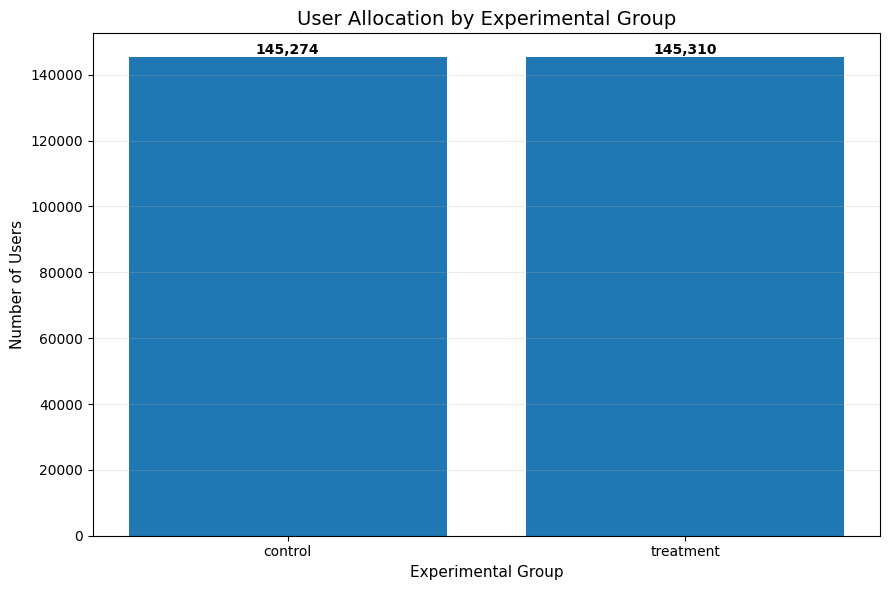

In [37]:
group_plot_data = group_summary.set_index("group")["user_count"]  # Prepare the experimental user counts for plotting.

fig, ax = plt.subplots(figsize=(9, 6))  # Create a figure and plotting area.

bars = ax.bar(group_plot_data.index, group_plot_data.values)  # Create a bar chart of user counts by group.

ax.set_title("User Allocation by Experimental Group")  # Add a descriptive chart title.

ax.set_xlabel("Experimental Group")  # Label the horizontal axis.

ax.set_ylabel("Number of Users")  # Label the vertical axis.

ax.ticklabel_format(style="plain", axis="y")  # Prevent scientific notation on the vertical axis.

ax.grid(axis="y", alpha=0.25)  # Add light horizontal grid lines for readability.

for bar in bars:  # Loop through each bar to create value labels.

    bar_height = bar.get_height()  # Extract the height of the current bar.

    ax.text(  # Add the user-count label above the current bar.
        bar.get_x() + bar.get_width() / 2,  # Position the label at the horizontal center of the bar.
        bar_height,  # Position the label at the top of the bar.
        f"{int(bar_height):,}",  # Format the user count with comma separators.
        ha="center",  # Horizontally center the text.
        va="bottom",  # Position the text immediately above the bar.
        fontweight="bold"  # Display the value label in bold.
    )

plt.tight_layout()  # Adjust spacing to prevent labels from being cut off.

plt.show()  # Display the completed chart.

In [91]:
plt.savefig("/content/Image/User Allocation by Experimental Group", dpi=300, bbox_inches="tight")

<Figure size 1000x600 with 0 Axes>

## Sample Ratio Mismatch Test

A Sample Ratio Mismatch test determines whether the observed experimental allocation differs significantly from the planned allocation.

For this project, the expected allocation is assumed to be:

- 50% control
- 50% treatment

### Hypotheses

- **Null hypothesis:** The observed group allocation follows the expected 50/50 ratio.
- **Alternative hypothesis:** The observed group allocation differs from the expected 50/50 ratio.

A chi-square goodness-of-fit test is used.

If the p-value is below 0.05, the experiment may contain a randomization, assignment, or tracking problem.

In [38]:
from scipy.stats import chisquare  # Import the chi-square goodness-of-fit test for the sample-ratio analysis.

observed_group_counts = analysis_df["group"].value_counts().sort_index()  # Count users in each experiment group and sort the group labels.

expected_group_counts = np.repeat(observed_group_counts.sum() / 2, 2)  # Calculate the expected user count for an equal 50/50 allocation.

srm_chi_square, srm_p_value = chisquare(  # Perform the Sample Ratio Mismatch chi-square test.
    f_obs=observed_group_counts.values,  # Provide the observed control and treatment counts.
    f_exp=expected_group_counts  # Provide the expected equal-allocation counts.
)

print("Observed group counts:")  # Display a heading for the actual allocation.

display(observed_group_counts.rename("observed_count").to_frame())  # Display observed group counts.

print("Expected group counts under a 50/50 allocation:")  # Display a heading for the expected allocation.

display(pd.DataFrame({  # Create a table of expected group counts.
    "group": observed_group_counts.index,  # Use the observed group names.
    "expected_count": expected_group_counts  # Include the expected user counts.
}))  # Complete and display the expected-allocation table.

print(f"Chi-square statistic: {srm_chi_square:.6f}")  # Display the Sample Ratio Mismatch test statistic.

print(f"P-value: {srm_p_value:.6f}")  # Display the Sample Ratio Mismatch p-value.

Observed group counts:


,observed_count
group,
control,145274
treatment,145310


Expected group counts under a 50/50 allocation:


,group,expected_count
0,control,"145,292.000000"
1,treatment,"145,292.000000"


Chi-square statistic: 0.004460
P-value: 0.946754


In [39]:
alpha = 0.05  # Define the statistical significance level for the Sample Ratio Mismatch test.

if srm_p_value < alpha:  # Check whether the p-value is below the selected significance level.

    print("Conclusion: Reject the null hypothesis.")  # Report rejection of the expected allocation assumption.

    print("The observed group allocation differs significantly from the expected 50/50 ratio.")  # Explain the statistical conclusion.

    print("The experiment should be investigated for possible randomization or tracking issues.")  # Provide the business and data-quality implication.

else:  # Handle the case where the allocation difference is not statistically significant.

    print("Conclusion: Fail to reject the null hypothesis.")  # Report that there is insufficient evidence against equal allocation.

    print("There is no evidence of a Sample Ratio Mismatch.")  # State the main experiment-validity conclusion.

    print("The observed group allocation is consistent with the expected 50/50 ratio.")  # Explain that allocation appears acceptable.

Conclusion: Fail to reject the null hypothesis.
There is no evidence of a Sample Ratio Mismatch.
The observed group allocation is consistent with the expected 50/50 ratio.


In [40]:
overall_non_conversions = total_users - total_conversions  # Calculate the number of users who did not convert.

overall_conversion_summary = pd.DataFrame({  # Create an overall conversion summary table.
    "Outcome": ["Not Converted", "Converted", "Total"],  # Define conversion-outcome labels.

    "User Count": [  # Define the user counts for each outcome.
        overall_non_conversions,  # Insert the non-converted user count.
        total_conversions,  # Insert the converted user count.
        total_users  # Insert the total experiment user count.
    ],  # Complete the user-count list.

    "Percentage": [  # Define the percentage values for each outcome.
        overall_non_conversions / total_users * 100,  # Calculate the percentage of non-converted users.
        total_conversions / total_users * 100,  # Calculate the percentage of converted users.
        100.0  # Assign 100% to the total row.
    ]  # Complete the percentage list.
})  # Complete the overall conversion summary table.

display(overall_conversion_summary)  # Display the overall conversion counts and percentages.

print(f"Overall conversion rate: {overall_conversion_rate:.4%}")  # Display the overall conversion rate using percentage formatting.

,Outcome,User Count,Percentage
0,Not Converted,255831,88.040291
1,Converted,34753,11.959709
2,Total,290584,100.000000


Overall conversion rate: 11.9597%


### Visualize Overall Conversion Outcomes

A bar chart is used to compare converted and non-converted users.

The chart also demonstrates the class distribution of the binary response variable.

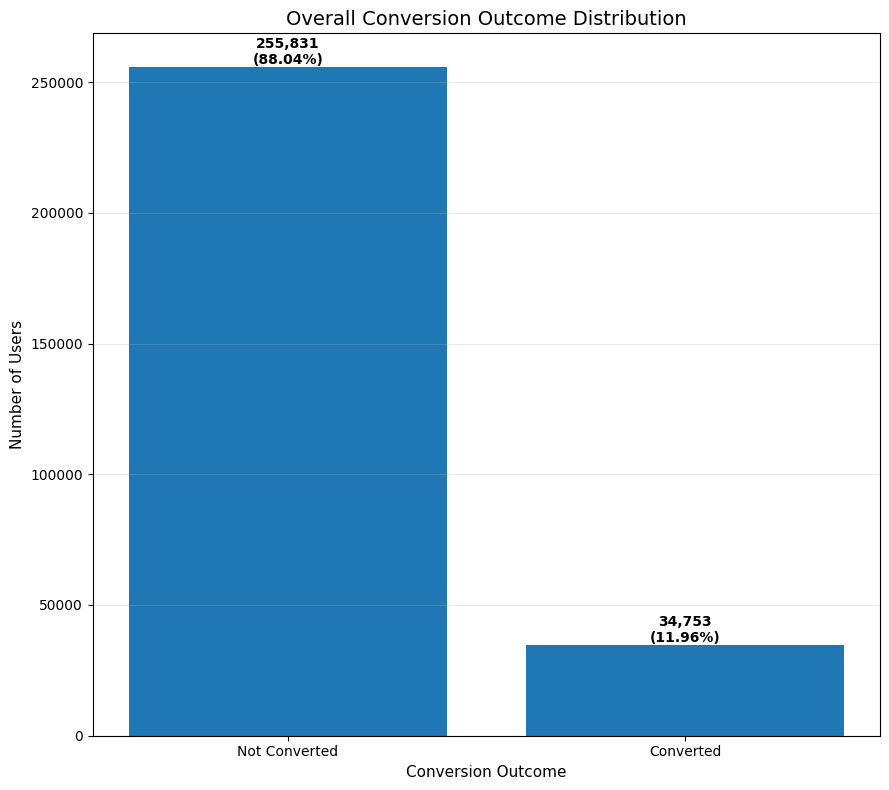

In [41]:
conversion_count_data = analysis_df["converted"].value_counts().sort_index()  # Count users for each conversion outcome.

conversion_count_data.index = ["Not Converted", "Converted"]  # Replace binary values with readable labels.

fig, ax = plt.subplots(figsize=(9, 8))  # Create a figure and plotting area.

bars = ax.bar(conversion_count_data.index, conversion_count_data.values)  # Create the conversion-outcome bar chart.

ax.set_title("Overall Conversion Outcome Distribution")  # Add a descriptive chart title.

ax.set_xlabel("Conversion Outcome")  # Label the horizontal axis.

ax.set_ylabel("Number of Users")  # Label the vertical axis.

ax.ticklabel_format(style="plain", axis="y")  # Prevent scientific notation on the vertical axis.

ax.grid(axis="y", alpha=0.25)  # Add light horizontal grid lines.

for bar in bars:  # Loop through the bars to add value labels.

    bar_height = bar.get_height()  # Extract the height of the current bar.

    bar_percentage = bar_height / total_users * 100  # Calculate the percentage represented by the current bar.

    ax.text(  # Add a count and percentage label above the current bar.
        bar.get_x() + bar.get_width() / 2,  # Position the label at the horizontal center of the bar.
        bar_height,  # Position the label at the top of the bar.
        f"{int(bar_height):,}\n({bar_percentage:.2f}%)",  # Display both user count and percentage.
        ha="center",  # Horizontally center the label.
        va="bottom",  # Position the label immediately above the bar.
        fontweight="bold"  # Display the label in bold.
    )

plt.tight_layout()  # Adjust chart spacing.

plt.show()  # Display the completed chart.

In [42]:
conversion_by_group = analysis_df.groupby("group", observed=False).agg(  # Group the analytical dataset by experiment assignment.
    total_users=("user_id", "nunique"),  # Count unique users in each group.
    conversions=("converted", "sum"),  # Count converted users in each group.
    conversion_rate=("converted", "mean")  # Calculate each group's conversion rate.
).reset_index()  # Convert the grouped result into a regular DataFrame.

conversion_by_group["non_conversions"] = conversion_by_group["total_users"] - conversion_by_group["conversions"]  # Calculate non-converted users in each group.

conversion_by_group["conversion_percentage"] = conversion_by_group["conversion_rate"] * 100  # Convert conversion rates into percentage values.

display(conversion_by_group)  # Display the group-level conversion summary.

,group,total_users,conversions,conversion_rate,non_conversions,conversion_percentage
0,control,145274,17489,0.120386,127785,12.038630
1,treatment,145310,17264,0.118808,128046,11.880807


In [43]:
control_conversion_rate = analysis_df.loc[  # Select the conversion outcome for control-group users.
    analysis_df["group"] == "control",  # Filter observations belonging to the control group.
    "converted"  # Select the binary conversion variable.
].mean()  # Calculate the control-group conversion rate.

treatment_conversion_rate = analysis_df.loc[  # Select the conversion outcome for treatment-group users.
    analysis_df["group"] == "treatment",  # Filter observations belonging to the treatment group.
    "converted"  # Select the binary conversion variable.
].mean()  # Calculate the treatment-group conversion rate.

absolute_lift = treatment_conversion_rate - control_conversion_rate  # Calculate the absolute treatment-control conversion difference.

absolute_lift_percentage_points = absolute_lift * 100  # Convert the absolute lift into percentage points.

relative_lift = absolute_lift / control_conversion_rate  # Calculate the treatment effect relative to the control conversion rate.

relative_lift_percentage = relative_lift * 100  # Convert the relative lift into a percentage.

In [44]:
lift_summary = pd.DataFrame({  # Create a summary table for conversion performance and treatment lift.
    "Metric": [  # Define the reported conversion metrics.
        "Control conversion rate",  # Conversion rate for the old page.
        "Treatment conversion rate",  # Conversion rate for the new page.
        "Absolute lift",  # Raw treatment-control difference.
        "Absolute lift in percentage points",  # Difference expressed in percentage points.
        "Relative lift"  # Proportional change relative to the control rate.
    ],  # Complete the metric-name list.

    "Value": [  # Define the corresponding metric values.
        control_conversion_rate,  # Insert the control conversion rate.
        treatment_conversion_rate,  # Insert the treatment conversion rate.
        absolute_lift,  # Insert the raw absolute treatment effect.
        absolute_lift_percentage_points,  # Insert the percentage-point effect.
        relative_lift_percentage  # Insert the relative percentage effect.
    ]  # Complete the metric-value list.
})  # Complete the lift-summary table.

display(lift_summary)  # Display the conversion-lift summary.

print(f"Control conversion rate: {control_conversion_rate:.4%}")  # Display the control conversion rate.

print(f"Treatment conversion rate: {treatment_conversion_rate:.4%}")  # Display the treatment conversion rate.

print(f"Absolute lift: {absolute_lift_percentage_points:.4f} percentage points")  # Display the percentage-point difference.

print(f"Relative lift: {relative_lift_percentage:.4f}%")  # Display the relative conversion change.

,Metric,Value
0,Control conversion rate,0.120386
1,Treatment conversion rate,0.118808
2,Absolute lift,-0.001578
3,Absolute lift in percentage points,-0.157824
4,Relative lift,-1.310979


Control conversion rate: 12.0386%
Treatment conversion rate: 11.8808%
Absolute lift: -0.1578 percentage points
Relative lift: -1.3110%


### Visualize Conversion Rates by Group

A conversion-rate bar chart compares the observed performance of the control and treatment groups.

The values are displayed as percentages to improve business interpretation.

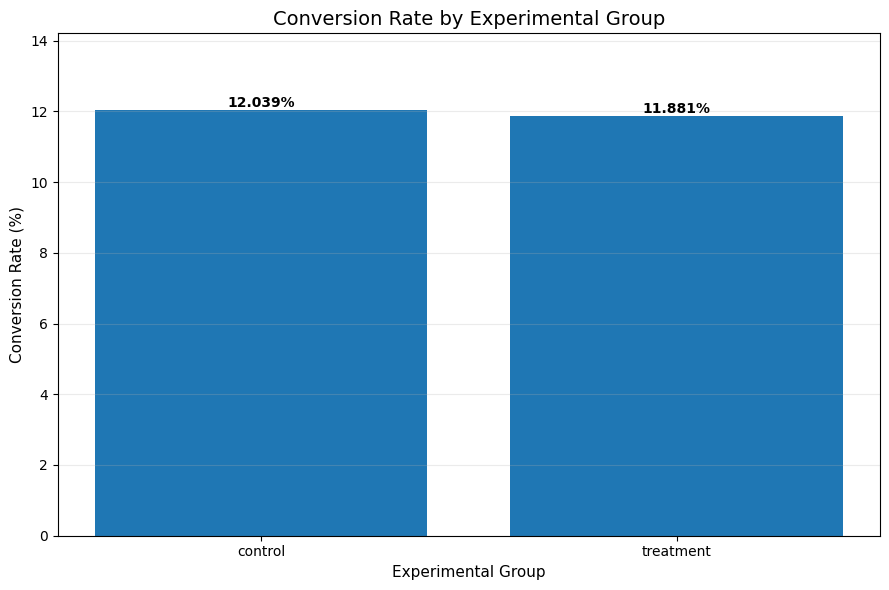

In [45]:
conversion_plot_data = conversion_by_group.set_index("group")["conversion_percentage"]  # Prepare group conversion percentages for plotting.

fig, ax = plt.subplots(figsize=(9, 6))  # Create a figure and plotting area.

bars = ax.bar(conversion_plot_data.index, conversion_plot_data.values)  # Create a conversion-rate bar chart.

ax.set_title("Conversion Rate by Experimental Group")  # Add a descriptive chart title.

ax.set_xlabel("Experimental Group")  # Label the horizontal axis.

ax.set_ylabel("Conversion Rate (%)")  # Label the vertical axis.

ax.grid(axis="y", alpha=0.25)  # Add light horizontal grid lines.

maximum_conversion_value = conversion_plot_data.max()  # Identify the highest conversion percentage for axis formatting.

ax.set_ylim(0, maximum_conversion_value * 1.18)  # Add vertical space above the bars for value labels.

for bar in bars:  # Loop through each conversion-rate bar.

    bar_height = bar.get_height()  # Extract the height of the current bar.

    ax.text(  # Add the conversion-rate label above the current bar.
        bar.get_x() + bar.get_width() / 2,  # Position the label at the horizontal center of the bar.
        bar_height,  # Position the label at the top of the bar.
        f"{bar_height:.3f}%",  # Display the conversion percentage using three decimal places.
        ha="center",  # Horizontally center the label.
        va="bottom",  # Position the label immediately above the bar.
        fontweight="bold"  # Display the label in bold.
    )

plt.tight_layout()  # Adjust chart spacing.

plt.show()  # Display the completed chart.

In [46]:
feature_engineered_file_path = "/content/ab_testing_feature_engineered.csv"  # Define the output path for the feature-engineered dataset.

analysis_df.to_csv(feature_engineered_file_path, index=False)  # Save the expanded analytical dataset without an additional index column.

print(f"Feature-engineered dataset saved successfully: {feature_engineered_file_path}")  # Confirm that the expanded dataset was saved.

Feature-engineered dataset saved successfully: /content/ab_testing_feature_engineered.csv


# Country and Time-Based Analysis

## Country-Level Conversion Analysis

This section examines whether conversion behavior varies across countries and whether the control and treatment pages perform differently within each country.

Country-level results are descriptive at this stage. Statistical relationships will later be examined through logistic regression.

In [47]:
# Overall conversion performance by country
country_summary = (
    analysis_df.groupby("country")
    .agg(
        users=("user_id", "nunique"),
        conversions=("converted", "sum"),
        conversion_rate=("converted", "mean")
    )
    .reset_index()
)

country_summary["conversion_rate_pct"] = country_summary["conversion_rate"] * 100
display(country_summary)

,country,users,conversions,conversion_rate,conversion_rate_pct
0,CA,14499,1672,0.115318,11.531830
1,UK,72466,8739,0.120594,12.059449
2,US,203619,24342,0.119547,11.954680


In [48]:
# Conversion performance by country and experimental group
country_group_summary = (
    analysis_df.groupby(["country", "group"])
    .agg(
        users=("user_id", "nunique"),
        conversions=("converted", "sum"),
        conversion_rate=("converted", "mean")
    )
    .reset_index()
)

country_group_summary["conversion_rate_pct"] = (
    country_group_summary["conversion_rate"] * 100
)

display(country_group_summary)

,country,group,users,conversions,conversion_rate,conversion_rate_pct
0,CA,control,7198,855,0.118783,11.878300
1,CA,treatment,7301,817,0.111902,11.190248
2,UK,control,36360,4364,0.120022,12.002200
3,UK,treatment,36106,4375,0.121171,12.117100
4,US,control,101716,12270,0.120630,12.062999
5,US,treatment,101903,12072,0.118466,11.846560


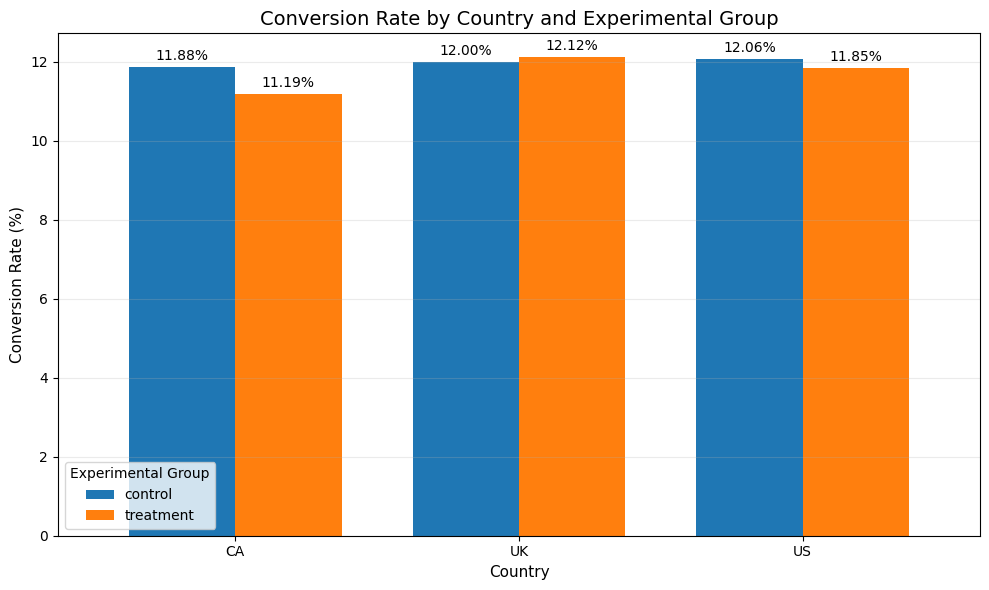

In [49]:
country_plot = country_group_summary.pivot(
    index="country",
    columns="group",
    values="conversion_rate_pct"
)

ax = country_plot.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

ax.set_title("Conversion Rate by Country and Experimental Group")
ax.set_xlabel("Country")
ax.set_ylabel("Conversion Rate (%)")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.legend(title="Experimental Group")
plt.tight_layout()
plt.show()

In [90]:
plt.savefig("/content/Image/Conversion Rate by Country and Experimental Group", dpi=300, bbox_inches="tight")

<Figure size 1000x600 with 0 Axes>

##  Weekday and Weekend Conversion Analysis

Conversion rates are compared between weekdays and weekends.

The analysis also checks whether the old and new pages behave differently across these two day types.

In [50]:
day_type_summary = (
    analysis_df.groupby(["day_type", "group"], observed=False)
    .agg(
        users=("user_id", "nunique"),
        conversions=("converted", "sum"),
        conversion_rate=("converted", "mean")
    )
    .reset_index()
)

day_type_summary["conversion_rate_pct"] = (
    day_type_summary["conversion_rate"] * 100
)

display(day_type_summary)

,day_type,group,users,conversions,conversion_rate,conversion_rate_pct
0,Weekday,control,105376,12620,0.119762,11.976162
1,Weekday,treatment,105624,12611,0.119395,11.939521
2,Weekend,control,39898,4869,0.122036,12.203619
3,Weekend,treatment,39686,4653,0.117245,11.724538


##  Weekday and Weekend Conversion Analysis

Conversion rates are compared between weekdays and weekends.

The analysis also checks whether the old and new pages behave differently across these two day types.

In [51]:
time_period_summary = (
    analysis_df.groupby(["time_period", "group"], observed=False)
    .agg(
        users=("user_id", "nunique"),
        conversions=("converted", "sum"),
        conversion_rate=("converted", "mean")
    )
    .reset_index()
)

time_period_summary["conversion_rate_pct"] = (
    time_period_summary["conversion_rate"] * 100
)

display(time_period_summary)

,time_period,group,users,conversions,conversion_rate,conversion_rate_pct
0,Morning,control,42552,5214,0.122532,12.253243
1,Morning,treatment,42273,5011,0.118539,11.853902
2,Afternoon,control,30018,3632,0.120994,12.099407
3,Afternoon,treatment,30531,3647,0.119452,11.945236
4,Evening,control,24382,2898,0.118858,11.885817
5,Evening,treatment,24147,2978,0.123328,12.332795
6,Night,control,48322,5745,0.118890,11.888995
7,Night,treatment,48359,5628,0.116380,11.637958


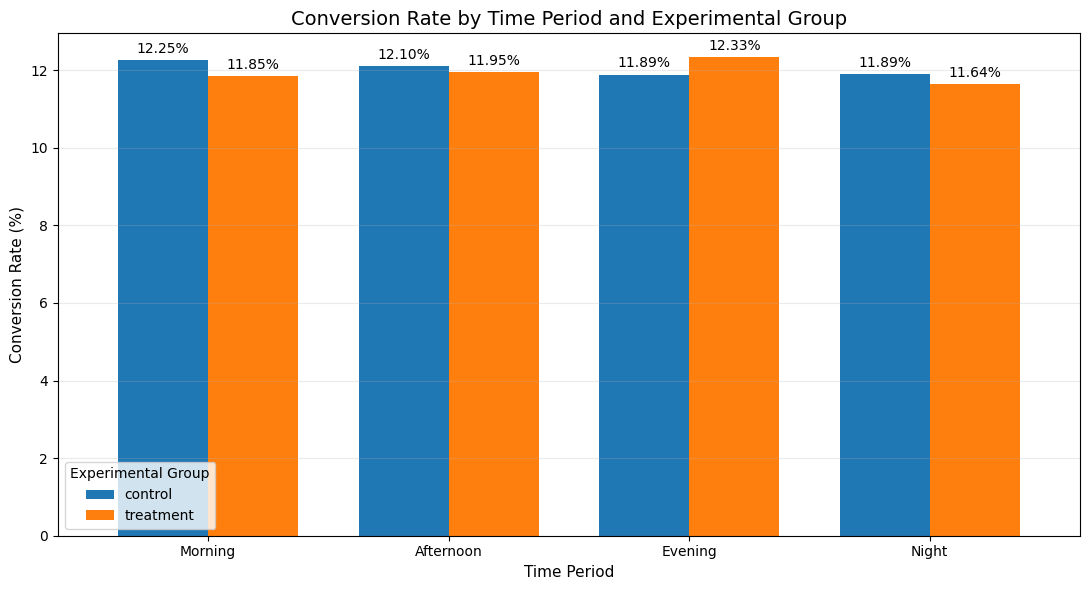

In [52]:
time_plot = time_period_summary.pivot(
    index="time_period",
    columns="group",
    values="conversion_rate_pct"
)

ax = time_plot.plot(
    kind="bar",
    figsize=(11, 6),
    width=0.75
)

ax.set_title("Conversion Rate by Time Period and Experimental Group")
ax.set_xlabel("Time Period")
ax.set_ylabel("Conversion Rate (%)")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.legend(title="Experimental Group")
plt.tight_layout()
plt.show()

In [54]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_summary = (
    analysis_df.groupby("day_name")
    .agg(
        users=("user_id", "nunique"),
        conversions=("converted", "sum"),
        conversion_rate=("converted", "mean")
    )
    .reset_index()
)

weekday_summary["day_name"] = pd.Categorical(
    weekday_summary["day_name"],
    categories=weekday_order,
    ordered=True
)

weekday_summary = weekday_summary.sort_values("day_name")
weekday_summary["conversion_rate_pct"] = weekday_summary["conversion_rate"] * 100

display(weekday_summary)

,day_name,users,conversions,conversion_rate,conversion_rate_pct
1,Monday,45440,5505,0.121149,12.114877
5,Tuesday,47148,5636,0.119538,11.953847
6,Wednesday,39565,4761,0.120334,12.033363
4,Thursday,39221,4705,0.119961,11.996125
0,Friday,39626,4624,0.116691,11.669106
2,Saturday,39669,4793,0.120825,12.082483
3,Sunday,39915,4729,0.118477,11.847676


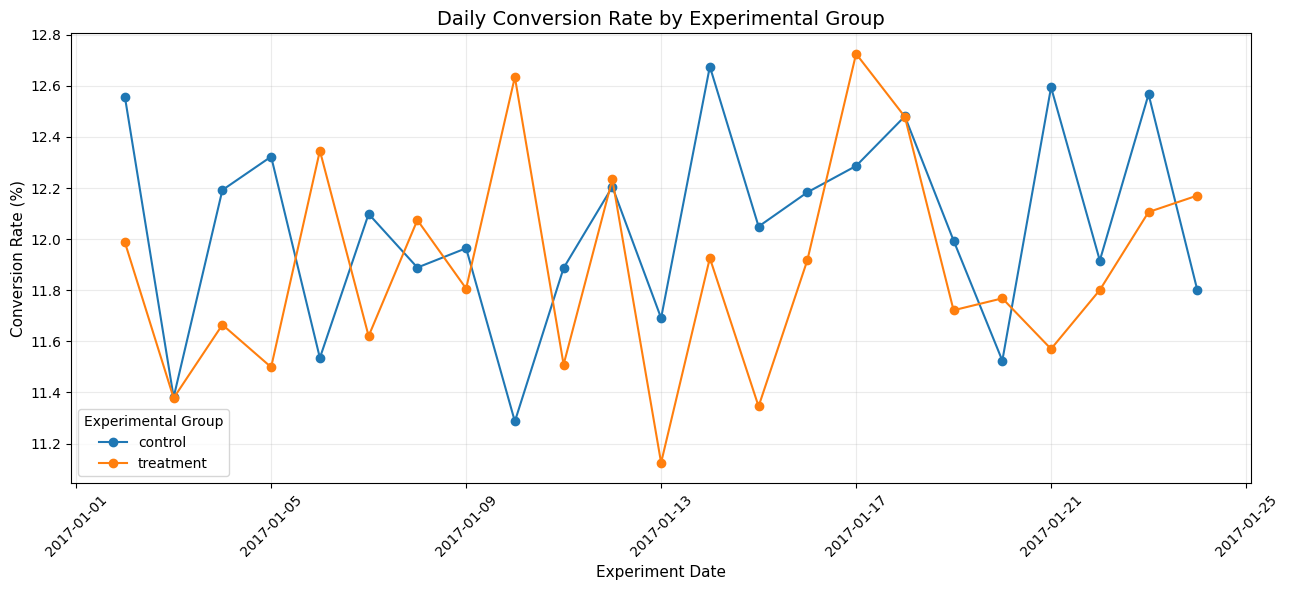

In [55]:
daily_conversion = (
    analysis_df.groupby(["date", "group"])
    .agg(
        users=("user_id", "nunique"),
        conversions=("converted", "sum"),
        conversion_rate=("converted", "mean")
    )
    .reset_index()
)

daily_conversion["conversion_rate_pct"] = (
    daily_conversion["conversion_rate"] * 100
)

daily_plot = daily_conversion.pivot(
    index="date",
    columns="group",
    values="conversion_rate_pct"
)

ax = daily_plot.plot(
    figsize=(13, 6),
    marker="o"
)

ax.set_title("Daily Conversion Rate by Experimental Group")
ax.set_xlabel("Experiment Date")
ax.set_ylabel("Conversion Rate (%)")
ax.grid(alpha=0.25)

plt.legend(title="Experimental Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [89]:
plt.savefig("/content/Image/Daily Conversion Rate by Experimental Group", dpi=300, bbox_inches="tight")

<Figure size 1000x600 with 0 Axes>

# Statistical Hypothesis Testing

## Hypothesis Definition

The primary business question is whether the new landing page produces a higher conversion rate than the old landing page.

Let:

- \(p_{new}\) represent the treatment-group conversion rate.
- \(p_{old}\) represent the control-group conversion rate.

### Primary One-Sided Hypotheses

- **Null hypothesis:** \(p_{new} \leq p_{old}\)
- **Alternative hypothesis:** \(p_{new} > p_{old}\)

The significance level is set to 5%.

A two-sided test will also be reported as a supplementary analysis.

In [56]:
alpha = 0.05

control_data = analysis_df.loc[
    analysis_df["group"] == "control", "converted"
]

treatment_data = analysis_df.loc[
    analysis_df["group"] == "treatment", "converted"
]

n_control = control_data.count()
n_treatment = treatment_data.count()

control_conversions = control_data.sum()
treatment_conversions = treatment_data.sum()

control_rate = control_data.mean()
treatment_rate = treatment_data.mean()

observed_difference = treatment_rate - control_rate

experiment_statistics = pd.DataFrame({
    "Group": ["Control / Old Page", "Treatment / New Page"],
    "Users": [n_control, n_treatment],
    "Conversions": [control_conversions, treatment_conversions],
    "Conversion Rate": [control_rate, treatment_rate],
    "Conversion Rate (%)": [control_rate * 100, treatment_rate * 100]
})

display(experiment_statistics)

print(f"Observed treatment effect: {observed_difference * 100:.4f} percentage points")

,Group,Users,Conversions,Conversion Rate,Conversion Rate (%)
0,Control / Old Page,145274,17489,0.120386,12.038630
1,Treatment / New Page,145310,17264,0.118808,11.880807


Observed treatment effect: -0.1578 percentage points


In [57]:
conversion_counts = np.array([
    treatment_conversions,
    control_conversions
])

group_sizes = np.array([
    n_treatment,
    n_control
])

# Primary one-sided test: treatment conversion > control conversion
z_stat_one_sided, p_value_one_sided = proportions_ztest(
    count=conversion_counts,
    nobs=group_sizes,
    alternative="larger"
)

# Supplementary two-sided test: treatment conversion != control conversion
z_stat_two_sided, p_value_two_sided = proportions_ztest(
    count=conversion_counts,
    nobs=group_sizes,
    alternative="two-sided"
)

print(f"One-sided z-statistic: {z_stat_one_sided:.4f}")
print(f"One-sided p-value: {p_value_one_sided:.6f}")

print(f"\nTwo-sided z-statistic: {z_stat_two_sided:.4f}")
print(f"Two-sided p-value: {p_value_two_sided:.6f}")

One-sided z-statistic: -1.3109
One-sided p-value: 0.905058

Two-sided z-statistic: -1.3109
Two-sided p-value: 0.189883


In [58]:
if p_value_one_sided < alpha:
    print("Reject the null hypothesis.")
    print("There is statistically significant evidence that the new page improves conversion.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is insufficient evidence that the new page improves conversion.")

Fail to reject the null hypothesis.
There is insufficient evidence that the new page improves conversion.


In [59]:
standard_error = np.sqrt(
    treatment_rate * (1 - treatment_rate) / n_treatment
    + control_rate * (1 - control_rate) / n_control
)

critical_value = norm.ppf(1 - alpha / 2)

ci_lower = observed_difference - critical_value * standard_error
ci_upper = observed_difference + critical_value * standard_error

print(f"Observed difference: {observed_difference * 100:.4f} percentage points")
print(f"95% CI lower bound: {ci_lower * 100:.4f} percentage points")
print(f"95% CI upper bound: {ci_upper * 100:.4f} percentage points")

Observed difference: -0.1578 percentage points
95% CI lower bound: -0.3938 percentage points
95% CI upper bound: 0.0781 percentage points


In [60]:
n_simulations = 10_000
rng = np.random.default_rng(42)

pooled_conversion_rate = (
    control_conversions + treatment_conversions
) / (
    n_control + n_treatment
)

simulated_treatment_rates = (
    rng.binomial(n_treatment, pooled_conversion_rate, n_simulations)
    / n_treatment
)

simulated_control_rates = (
    rng.binomial(n_control, pooled_conversion_rate, n_simulations)
    / n_control
)

simulated_differences = (
    simulated_treatment_rates - simulated_control_rates
)

simulation_p_value = (
    np.sum(simulated_differences >= observed_difference) + 1
) / (
    n_simulations + 1
)

print(f"Simulation-based p-value: {simulation_p_value:.6f}")

Simulation-based p-value: 0.902910


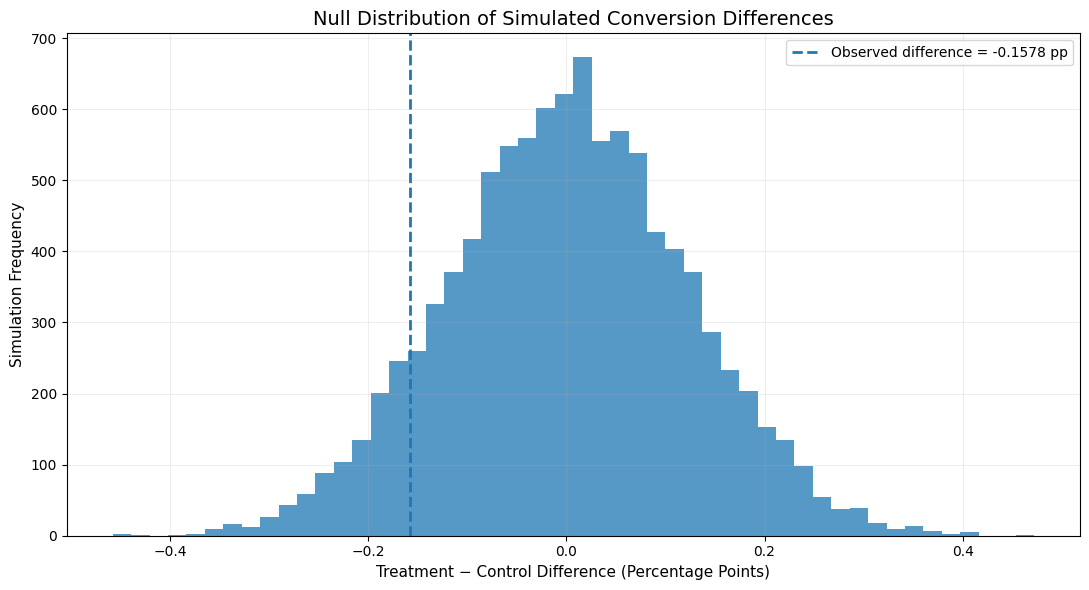

In [61]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.hist(
    simulated_differences * 100,
    bins=50,
    alpha=0.75
)

ax.axvline(
    observed_difference * 100,
    linestyle="--",
    linewidth=2,
    label=f"Observed difference = {observed_difference * 100:.4f} pp"
)

ax.set_title("Null Distribution of Simulated Conversion Differences")
ax.set_xlabel("Treatment − Control Difference (Percentage Points)")
ax.set_ylabel("Simulation Frequency")
ax.grid(alpha=0.20)
ax.legend()

plt.tight_layout()
plt.show()

In [88]:
plt.savefig("/content/Image/Null Distribution of Simulated Conversion Differences", dpi=300, bbox_inches="tight")

<Figure size 1000x600 with 0 Axes>

#  Logistic Regression Analysis

## Logistic Regression Overview

Logistic regression is appropriate because the response variable, `converted`, is binary.

The models will estimate how the odds of conversion are associated with:

- Landing-page assignment
- Country
- Weekend status
- Time of day
- Experiment day
- Page and country interaction effects

The analysis focuses primarily on statistical inference rather than individual-level prediction.

In [62]:
import statsmodels.formula.api as smf

from scipy.stats import chi2
from sklearn.metrics import roc_auc_score, roc_curve
from statsmodels.stats.outliers_influence import variance_inflation_factor

## Prepare the Regression Dataset

Reference categories are explicitly defined to make coefficient interpretation consistent.

Reference categories:

- Country: Canada
- Time period: Morning
- Page: Control / Old Page

In [63]:
regression_df = analysis_df.copy()

regression_df["country"] = pd.Categorical(
    regression_df["country"],
    categories=["CA", "UK", "US"]
)

regression_df["time_period"] = pd.Categorical(
    regression_df["time_period"],
    categories=["Morning", "Afternoon", "Evening", "Night"],
    ordered=True
)

regression_df["converted"] = regression_df["converted"].astype(int)
regression_df["ab_page"] = regression_df["ab_page"].astype(int)

print("Regression dataset prepared successfully.")

Regression dataset prepared successfully.


In [64]:
model_1 = smf.logit(
    formula="converted ~ ab_page",
    data=regression_df
).fit(disp=False)

display(model_1.summary2().tables[1])

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,-1.988777,0.008063,-246.669004,0.000000,-2.004579,-1.972975
ab_page,-0.014989,0.011434,-1.310916,0.189886,-0.037399,0.007421


## Model 2: Landing Page and Country

The second model adjusts the estimated page effect for country.

\[
Conversion \sim Page + Country
\]

In [65]:
model_2 = smf.logit(
    formula="converted ~ ab_page + C(country)",
    data=regression_df
).fit(disp=False)

display(model_2.summary2().tables[1])

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,-2.030029,0.026624,-76.248769,0.000000,-2.082210,-1.977847
C(country)[T.UK],0.050640,0.028393,1.783532,0.074500,-0.005009,0.106290
C(country)[T.US],0.040757,0.026883,1.516071,0.129501,-0.011933,0.093447
ab_page,-0.014943,0.011434,-1.306905,0.191245,-0.037354,0.007467


Model 3: Adjusted Logistic Regression

The third model estimates the page effect while controlling for country and time-related variables.

\[
Conversion \sim Page + Country + Weekend + TimePeriod + ExperimentDay
\]

In [66]:
model_3 = smf.logit(
    formula=(
        "converted ~ ab_page + C(country) + "
        "is_weekend + C(time_period) + experiment_day"
    ),
    data=regression_df
).fit(disp=False)

display(model_3.summary2().tables[1])

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,-2.037256,0.030265,-67.313418,0.000000,-2.096574,-1.977937
C(country)[T.UK],0.050532,0.028394,1.779693,0.075126,-0.005119,0.106183
C(country)[T.US],0.040550,0.026884,1.508310,0.131475,-0.012142,0.093241
C(time_period)[T.Afternoon],-0.002253,0.016361,-0.137726,0.890457,-0.034320,0.029814
C(time_period)[T.Evening],0.006363,0.017484,0.363949,0.715896,-0.027905,0.040632
C(time_period)[T.Night],-0.027194,0.014525,-1.872211,0.061177,-0.055663,0.001275
ab_page,-0.014891,0.011434,-1.302297,0.192815,-0.037302,0.007520
is_weekend,-0.002187,0.012942,-0.169021,0.865780,-0.027553,0.023178
experiment_day,0.001353,0.000908,1.489433,0.136373,-0.000427,0.003133


##  Model 4: Page and Country Interaction

The interaction model tests whether the effect of the new landing page differs across countries.

\[
Conversion \sim Page \times Country + TimeControls
\]

A significant interaction term would suggest that the new page performs differently in a particular country.

In [67]:
model_4 = smf.logit(
    formula=(
        "converted ~ ab_page * C(country) + "
        "is_weekend + C(time_period) + experiment_day"
    ),
    data=regression_df
).fit(disp=False)

display(model_4.summary2().tables[1])

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
Intercept,-2.011311,0.039207,-51.300185,0.000000,-2.088155,-1.934468
C(country)[T.UK],0.011690,0.039846,0.293374,0.769237,-0.066407,0.089786
C(country)[T.US],0.017442,0.037682,0.462871,0.643457,-0.056414,0.091298
C(time_period)[T.Afternoon],-0.002370,0.016361,-0.144855,0.884825,-0.034437,0.029697
C(time_period)[T.Evening],0.006314,0.017484,0.361134,0.718000,-0.027955,0.040583
C(time_period)[T.Night],-0.027241,0.014525,-1.875443,0.060732,-0.055710,0.001228
ab_page,-0.067220,0.052015,-1.292304,0.196252,-0.169168,0.034729
ab_page:C(country)[T.UK],0.078258,0.056799,1.377807,0.168263,-0.033066,0.189582
ab_page:C(country)[T.US],0.046642,0.053780,0.867286,0.385785,-0.058764,0.152049
is_weekend,-0.002189,0.012942,-0.169151,0.865678,-0.027555,0.023177


In [68]:
def create_odds_ratio_table(model):
    confidence_interval = model.conf_int()

    results = pd.DataFrame({
        "coefficient": model.params,
        "odds_ratio": np.exp(model.params),
        "ci_lower": np.exp(confidence_interval[0]),
        "ci_upper": np.exp(confidence_interval[1]),
        "p_value": model.pvalues
    })

    results.index.name = "term"
    return results.reset_index()

In [69]:
models = {
    "Model 1: Page": model_1,
    "Model 2: Page + Country": model_2,
    "Model 3: Adjusted": model_3,
    "Model 4: Interaction": model_4
}

odds_ratio_tables = {}

for model_name, fitted_model in models.items():
    print(f"\n{model_name}")

    odds_ratio_tables[model_name] = create_odds_ratio_table(
        fitted_model
    )

    display(
        odds_ratio_tables[model_name].round(6)
    )


Model 1: Page


,term,coefficient,odds_ratio,ci_lower,ci_upper,p_value
0,Intercept,-1.988777,0.136863,0.134717,0.139043,0.000000
1,ab_page,-0.014989,0.985123,0.963291,1.007449,0.189886



Model 2: Page + Country


,term,coefficient,odds_ratio,ci_lower,ci_upper,p_value
0,Intercept,-2.030029,0.131332,0.124654,0.138367,0.000000
1,C(country)[T.UK],0.050640,1.051944,0.995003,1.112144,0.074500
2,C(country)[T.US],0.040757,1.041599,0.988138,1.097953,0.129501
3,ab_page,-0.014943,0.985168,0.963335,1.007495,0.191245



Model 3: Adjusted


,term,coefficient,odds_ratio,ci_lower,ci_upper,p_value
0,Intercept,-2.037256,0.130386,0.122877,0.138354,0.000000
1,C(country)[T.UK],0.050532,1.051831,0.994894,1.112026,0.075126
2,C(country)[T.US],0.040550,1.041383,0.987931,1.097727,0.131475
3,C(time_period)[T.Afternoon],-0.002253,0.997749,0.966262,1.030262,0.890457
4,C(time_period)[T.Evening],0.006363,1.006384,0.972481,1.041468,0.715896
5,C(time_period)[T.Night],-0.027194,0.973172,0.945858,1.001275,0.061177
6,ab_page,-0.014891,0.985219,0.963385,1.007548,0.192815
7,is_weekend,-0.002187,0.997815,0.972823,1.023449,0.865780
8,experiment_day,0.001353,1.001354,0.999573,1.003138,0.136373



Model 4: Interaction


,term,coefficient,odds_ratio,ci_lower,ci_upper,p_value
0,Intercept,-2.011311,0.133813,0.123916,0.144501,0.000000
1,C(country)[T.UK],0.011690,1.011758,0.935750,1.093940,0.769237
2,C(country)[T.US],0.017442,1.017595,0.945148,1.095596,0.643457
3,C(time_period)[T.Afternoon],-0.002370,0.997633,0.966149,1.030143,0.884825
4,C(time_period)[T.Evening],0.006314,1.006334,0.972432,1.041418,0.718000
5,C(time_period)[T.Night],-0.027241,0.973127,0.945813,1.001228,0.060732
6,ab_page,-0.067220,0.934990,0.844367,1.035339,0.196252
7,ab_page:C(country)[T.UK],0.078258,1.081401,0.967475,1.208744,0.168263
8,ab_page:C(country)[T.US],0.046642,1.047747,0.942929,1.164217,0.385785
9,is_weekend,-0.002189,0.997813,0.972821,1.023447,0.865678


In [70]:
model_comparison = pd.DataFrame({
    "Model": list(models.keys()),
    "AIC": [model.aic for model in models.values()],
    "BIC": [model.bic for model in models.values()],
    "Pseudo_R2": [model.prsquared for model in models.values()],
    "Log_Likelihood": [model.llf for model in models.values()],
    "Number_of_Predictors": [int(model.df_model) for model in models.values()]
})

display(model_comparison.round(6))

,Model,AIC,BIC,Pseudo_R2,Log_Likelihood,Number_of_Predictors
0,Model 1: Page,"212,780.350201","212,801.509497",0.000008,"-106,388.175101",1
1,Model 2: Page + Country,"212,781.125301","212,823.443893",0.000023,"-106,386.562651",3
2,Model 3: Adjusted,"212,783.419958","212,878.636790",0.000059,"-106,382.709979",8
3,Model 4: Interaction,"212,784.942780","212,901.318908",0.000071,"-106,381.471390",10


In [71]:
def likelihood_ratio_test(reduced_model, full_model):
    lr_statistic = 2 * (
        full_model.llf - reduced_model.llf
    )

    df_difference = int(
        full_model.df_model - reduced_model.df_model
    )

    p_value = chi2.sf(
        lr_statistic,
        df_difference
    )

    return lr_statistic, df_difference, p_value

In [72]:
model_pairs = [
    ("Model 1 vs Model 2", model_1, model_2),
    ("Model 2 vs Model 3", model_2, model_3),
    ("Model 3 vs Model 4", model_3, model_4)
]

lr_results = []

for comparison_name, reduced_model, full_model in model_pairs:
    lr_stat, df_diff, p_value = likelihood_ratio_test(
        reduced_model,
        full_model
    )

    lr_results.append({
        "Comparison": comparison_name,
        "LR Statistic": lr_stat,
        "DF Difference": df_diff,
        "P-value": p_value
    })

lr_test_summary = pd.DataFrame(lr_results)
display(lr_test_summary.round(6))

,Comparison,LR Statistic,DF Difference,P-value
0,Model 1 vs Model 2,3.224900,2,0.199398
1,Model 2 vs Model 3,7.705343,5,0.173240
2,Model 3 vs Model 4,2.477178,2,0.289793


In [74]:
model_3_design = model_3.model.exog
model_3_features = model_3.model.exog_names

vif_summary = pd.DataFrame({
    "Feature": model_3_features,
    "VIF": [
        variance_inflation_factor(model_3_design, index)
        for index in range(model_3_design.shape[1])
    ]
})

vif_summary = vif_summary.loc[
    vif_summary["Feature"] != "Intercept"
].reset_index(drop=True)

display(vif_summary.round(4))

,Feature,VIF
0,C(country)[T.UK],4.502300
1,C(country)[T.US],4.502400
2,C(time_period)[T.Afternoon],1.358300
3,C(time_period)[T.Evening],1.313200
4,C(time_period)[T.Night],1.428600
5,ab_page,1.000000
6,is_weekend,1.019500
7,experiment_day,1.022400


In [75]:
auc_results = []

for model_name, fitted_model in models.items():
    predicted_probabilities = fitted_model.predict(
        regression_df
    )

    auc_score = roc_auc_score(
        regression_df["converted"],
        predicted_probabilities
    )

    auc_results.append({
        "Model": model_name,
        "ROC_AUC": auc_score
    })

auc_summary = pd.DataFrame(auc_results)
display(auc_summary.round(6))

,Model,ROC_AUC
0,Model 1: Page,0.501874
1,Model 2: Page + Country,0.502857
2,Model 3: Adjusted,0.505409
3,Model 4: Interaction,0.505750


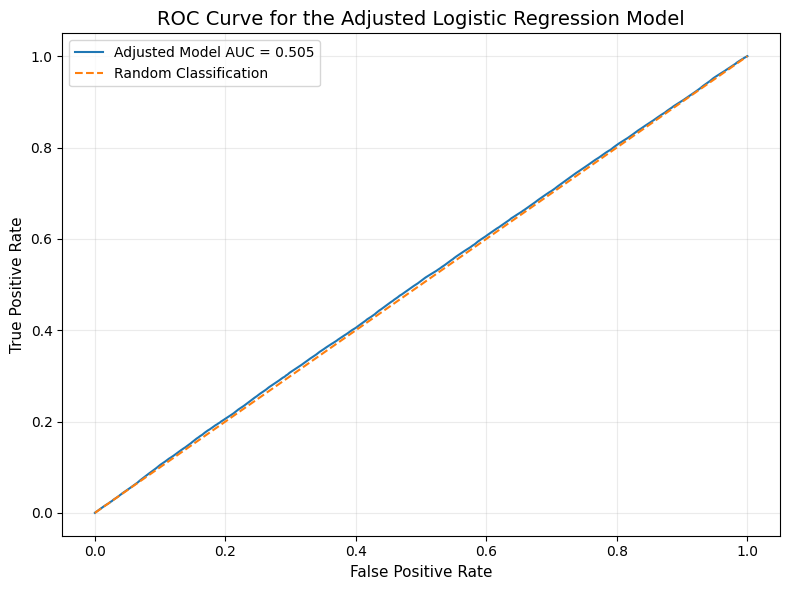

In [76]:
adjusted_probabilities = model_3.predict(
    regression_df
)

false_positive_rate, true_positive_rate, _ = roc_curve(
    regression_df["converted"],
    adjusted_probabilities
)

adjusted_auc = roc_auc_score(
    regression_df["converted"],
    adjusted_probabilities
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"Adjusted Model AUC = {adjusted_auc:.3f}"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classification"
)

ax.set_title("ROC Curve for the Adjusted Logistic Regression Model")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

In [87]:
plt.savefig("/content/Image/conversion_rate.png", dpi=300, bbox_inches="tight")

<Figure size 1000x600 with 0 Axes>

In [77]:
prediction_grid = pd.MultiIndex.from_product(
    [
        ["CA", "UK", "US"],
        [0, 1]
    ],
    names=["country", "ab_page"]
).to_frame(index=False)

prediction_grid["is_weekend"] = 0
prediction_grid["time_period"] = "Morning"
prediction_grid["experiment_day"] = regression_df["experiment_day"].median()

prediction_grid["country"] = pd.Categorical(
    prediction_grid["country"],
    categories=["CA", "UK", "US"]
)

prediction_grid["time_period"] = pd.Categorical(
    prediction_grid["time_period"],
    categories=["Morning", "Afternoon", "Evening", "Night"],
    ordered=True
)

prediction_grid["predicted_conversion"] = model_4.predict(
    prediction_grid
)

prediction_grid["predicted_conversion_pct"] = (
    prediction_grid["predicted_conversion"] * 100
)

prediction_grid["page"] = prediction_grid["ab_page"].map({
    0: "Old Page",
    1: "New Page"
})

display(prediction_grid)

,country,ab_page,is_weekend,time_period,experiment_day,predicted_conversion,predicted_conversion_pct,page
0,CA,0,0,Morning,12.000000,0.119725,11.972490,Old Page
1,CA,1,0,Morning,12.000000,0.112820,11.281967,New Page
2,UK,0,0,Morning,12.000000,0.120962,12.096237,Old Page
3,UK,1,0,Morning,12.000000,0.122141,12.214099,New Page
4,US,0,0,Morning,12.000000,0.121575,12.157536,Old Page
5,US,1,0,Morning,12.000000,0.119395,11.939488,New Page


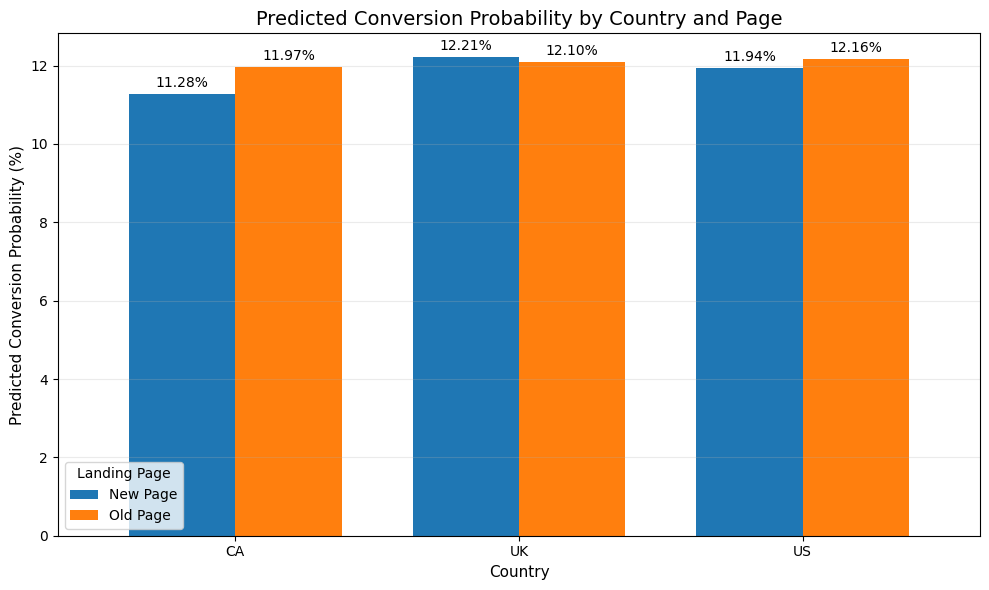

In [79]:
predicted_plot = prediction_grid.pivot(
    index="country",
    columns="page",
    values="predicted_conversion_pct"
)

ax = predicted_plot.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

ax.set_title("Predicted Conversion Probability by Country and Page")
ax.set_xlabel("Country")
ax.set_ylabel("Predicted Conversion Probability (%)")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.25)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.legend(title="Landing Page")
plt.tight_layout()
plt.show()

##Final Findings and Recommendation

In [80]:
page_odds_ratio = np.exp(
    model_1.params["ab_page"]
)

page_regression_p_value = model_1.pvalues[
    "ab_page"
]

print("KEY PROJECT RESULTS")
print("-" * 50)

print(f"Control conversion rate: {control_rate:.4%}")
print(f"Treatment conversion rate: {treatment_rate:.4%}")

print(
    f"Absolute treatment effect: "
    f"{observed_difference * 100:.4f} percentage points"
)

print(
    f"Relative treatment effect: "
    f"{observed_difference / control_rate * 100:.4f}%"
)

print(f"One-sided p-value: {p_value_one_sided:.6f}")
print(f"Two-sided p-value: {p_value_two_sided:.6f}")

print(
    f"95% confidence interval: "
    f"[{ci_lower * 100:.4f}, {ci_upper * 100:.4f}] "
    f"percentage points"
)

print(f"New-page odds ratio: {page_odds_ratio:.4f}")
print(f"Regression p-value: {page_regression_p_value:.6f}")

KEY PROJECT RESULTS
--------------------------------------------------
Control conversion rate: 12.0386%
Treatment conversion rate: 11.8808%
Absolute treatment effect: -0.1578 percentage points
Relative treatment effect: -1.3110%
One-sided p-value: 0.905058
Two-sided p-value: 0.189883
95% confidence interval: [-0.3938, 0.0781] percentage points
New-page odds ratio: 0.9851
Regression p-value: 0.189886


In [81]:
page_odds_ratio = np.exp(
    model_1.params["ab_page"]
)

page_regression_p_value = model_1.pvalues[
    "ab_page"
]

print("KEY PROJECT RESULTS")
print("-" * 50)

print(f"Control conversion rate: {control_rate:.4%}")
print(f"Treatment conversion rate: {treatment_rate:.4%}")

print(
    f"Absolute treatment effect: "
    f"{observed_difference * 100:.4f} percentage points"
)

print(
    f"Relative treatment effect: "
    f"{observed_difference / control_rate * 100:.4f}%"
)

print(f"One-sided p-value: {p_value_one_sided:.6f}")
print(f"Two-sided p-value: {p_value_two_sided:.6f}")

print(
    f"95% confidence interval: "
    f"[{ci_lower * 100:.4f}, {ci_upper * 100:.4f}] "
    f"percentage points"
)

print(f"New-page odds ratio: {page_odds_ratio:.4f}")
print(f"Regression p-value: {page_regression_p_value:.6f}")

KEY PROJECT RESULTS
--------------------------------------------------
Control conversion rate: 12.0386%
Treatment conversion rate: 11.8808%
Absolute treatment effect: -0.1578 percentage points
Relative treatment effect: -1.3110%
One-sided p-value: 0.905058
Two-sided p-value: 0.189883
95% confidence interval: [-0.3938, 0.0781] percentage points
New-page odds ratio: 0.9851
Regression p-value: 0.189886


In [82]:
final_dataset_path = (
    "/content/ab_testing_final_analytical_dataset.csv"
)

analysis_df.to_csv(
    final_dataset_path,
    index=False
)

print(
    f"Final analytical dataset saved successfully: "
    f"{final_dataset_path}"
)

Final analytical dataset saved successfully: /content/ab_testing_final_analytical_dataset.csv
